In [1]:
!ls

README.md	 dose.sif		  start_notebook_aron.sh
cacheing.sh	 knowledge.md		  start_notebook_zsofi.sh
checkpoints	 logs			  train.py
config_atlas.sh  notebooks		  train.sh
configs		 sample_script_runner.sh  utils
create_cache.py  scripts
data		 start_notebook.sh


In [2]:
import numpy as np
import torch
import matplotlib as plt
import seaborn
from monai.transforms import LoadImaged, Compose
import json
import os
import re
from collections import Counter
import pandas as pd

In [3]:
pip install --user openpyxl

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [3]:
!ls ../nr_dose_scratch/training/

1ABB006  1ABB070  1ABB143  1THB023  1THB076  1THB217
1ABB011  1ABB078  1ABB145  1THB027  1THB078  1THB218
1ABB020  1ABB083  1ABB147  1THB029  1THB095  1THB220
1ABB021  1ABB098  1ABB149  1THB031  1THB119  1THB221
1ABB030  1ABB102  1ABB155  1THB037  1THB120  1THB226
1ABB031  1ABB109  1ABB161  1THB043  1THB121  SynthRAD2025_image_parameters.xlsx
1ABB035  1ABB110  1ABB164  1THB045  1THB122  beam_parameters.json
1ABB036  1ABB115  1ABB169  1THB048  1THB143  train.json
1ABB039  1ABB118  1THB002  1THB052  1THB191  val.json
1ABB041  1ABB123  1THB008  1THB054  1THB195
1ABB042  1ABB124  1THB011  1THB058  1THB202
1ABB045  1ABB128  1THB016  1THB063  1THB205
1ABB061  1ABB135  1THB017  1THB067  1THB211
1ABB067  1ABB138  1THB021  1THB074  1THB214


In [4]:
dataPath = "/project/nr_dose_scratch/training"
sample = "1THB226" 

In [5]:
transforms = Compose([
    LoadImaged(keys=["HU"], image_only=False),
])

sample_dict = {"HU": f"{dataPath}/{sample}/image/ct.mha"}
data = transforms(sample_dict)
img,metadata = data["HU"], data["HU_meta_dict"]

In [6]:
metadata

{'Modality': 'MET_MOD_UNKNOWN',
 'spacing': array([1., 1., 3.]),
 original_affine: array([[  -1.,    0.,    0.,  220.],
        [   0.,   -1.,    0.,  226.],
        [   0.,    0.,    3., -186.],
        [   0.,    0.,    0.,    1.]]),
 space: RAS,
 affine: tensor([[  -1.,    0.,    0.,  220.],
         [   0.,   -1.,    0.,  226.],
         [   0.,    0.,    3., -186.],
         [   0.,    0.,    0.,    1.]], dtype=torch.float64),
 spatial_shape: array([450, 444, 125]),
 original_channel_dim: nan,
 'filename_or_obj': '/project/nr_dose_scratch/training/1THB226/image/ct.mha'}

In [7]:
json.load(open("/project/nr_dose_scratch/training/1ABB006/1ABB006.json"))

{'iso_center': [-16.1283, -62.0295, 73.9938],
 'beams': [{'beam_idx': 0,
   'gantry_angle': 0.0,
   'rays': [{'ray_idx': 0,
     'ray_source': [-16.13, -1062.03, 33.99],
     'ray_target': [-16.13, -62.02999999999997, 33.99],
     'beamlets': [{'beamlet_idx': 0, 'energy': 45.5978},
      {'beamlet_idx': 1, 'energy': 126.1016}]},
    {'ray_idx': 1,
     'ray_source': [8.87, -1062.03, 33.99],
     'ray_target': [8.87, -62.02999999999997, 33.99],
     'beamlets': [{'beamlet_idx': 0, 'energy': 118.4897},
      {'beamlet_idx': 1, 'energy': 112.5242}]},
    {'ray_idx': 2,
     'ray_source': [-41.13, -1062.03, 33.99],
     'ray_target': [-41.13, -62.02999999999997, 33.99],
     'beamlets': [{'beamlet_idx': 0, 'energy': 88.1344},
      {'beamlet_idx': 1, 'energy': 77.8749}]},
    {'ray_idx': 3,
     'ray_source': [-16.13, -1062.03, 53.99],
     'ray_target': [-16.13, -62.02999999999997, 53.99],
     'beamlets': [{'beamlet_idx': 0, 'energy': 180.517},
      {'beamlet_idx': 1, 'energy': 72.3349}

In [8]:
xlsx_path = "/project/nr_dose_scratch/training/SynthRAD2025_image_parameters.xlsx"

df = pd.read_excel(xlsx_path)

print(df.shape)
display(df.head())

(75, 23)


,ID,Set,PatientSex,PatientAge,Modality,StudyDate,StudyDescription,SeriesDescription,KVP,ExposureTime,...,CTDIvol,Rows,Columns,PixelSpacing,SliceThickness,DataCollectionDiameter,ReconstructionDiameter,Manufacturer,ManufacturerModelName,Slices
0,1ABB006,1,NaN,NaN,CT,20210810,Thorax/Abdomen,Body 5.0 CE,120,750,...,45907,512,512,"[0.625, 0.625]",5,320,320,TOSHIBA,Alexion,403
1,1ABB011,1,NaN,NaN,CT,20210427,empty,Koerperstamm 3.0,120,500,...,45731,512,512,"[1.367, 1.367]",3,700,700,TOSHIBA,Aquilion/LB,131
2,1ABB020,1,NaN,NaN,CT,20200417,empty,Koerperstamm 3.0 CE,120,500,...,45820,512,512,"[1.074, 1.074]",3,550,550,TOSHIBA,Aquilion/LB,106
3,1ABB021,1,NaN,NaN,CT,20210202,empty,Koerperstamm 3.0 CE,120,500,...,45818,512,512,"[1.367, 1.367]",3,700,700,TOSHIBA,Aquilion/LB,121
4,1ABB030,1,NaN,NaN,CT,20210128,empty,Koerperstamm 3.0 CE,120,500,...,8,512,512,"[1.367, 1.367]",3,700,700,TOSHIBA,Aquilion/LB,117


In [9]:
dataPath = "/project/nr_dose_scratch/training"
xlsx_path = "/project/nr_dose_scratch/training/SynthRAD2025_image_parameters.xlsx"

# Excel beolvasása
df = pd.read_excel(xlsx_path)

# Training ID-k kigyűjtése
samples = sorted([
    name for name in os.listdir(dataPath)
    if os.path.isdir(os.path.join(dataPath, name))
    and os.path.exists(os.path.join(dataPath, name, "image", "ct.mha"))
])

sample_set = set(samples)

# ID oszlop automatikus felismerése az Excelben
best_col = None
best_overlap = 0

for col in df.columns:
    values = set(df[col].astype(str).str.strip())
    overlap = len(values & sample_set)
    if overlap > best_overlap:
        best_overlap = overlap
        best_col = col

ID_COL = best_col

# PixelSpacing oszlop felismerése
PIXEL_COL = [
    col for col in df.columns
    if "pixel" in str(col).lower() and "spacing" in str(col).lower()
][0]

print("ID column:", ID_COL)
print("PixelSpacing column:", PIXEL_COL)
print("Matched IDs:", best_overlap, "/", len(samples))


def parse_pixel_spacing(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return [float(v) for v in np.array(x).reshape(-1)]
    
    if pd.isna(x):
        return None
    
    nums = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", str(x))
    return [float(n) for n in nums]


# Excel PixelSpacing értékek ID szerint
pixel_spacing_dict = {}

for _, row in df.iterrows():
    sample_id = str(row[ID_COL]).strip()
    pixel_spacing_dict[sample_id] = parse_pixel_spacing(row[PIXEL_COL])


# MONAI loader
transforms = Compose([
    LoadImaged(keys=["HU"], image_only=False)
])

# image_info_dict létrehozása
image_info_dict = {}

for sample in samples:
    ct_path = os.path.join(dataPath, sample, "image", "ct.mha")

    data = transforms({"HU": ct_path})
    metadata = data["HU_meta_dict"]

    spatial_shape = np.array(metadata["spatial_shape"], dtype=int).tolist()

    image_info_dict[sample] = {
        "spatial_shape": spatial_shape,
        "PixelSpacing_excel": pixel_spacing_dict.get(sample, None),
    }

# Ellenőrzés
print("Number of entries:", len(image_info_dict))
list(image_info_dict.items())[:3]

ID column: ID
PixelSpacing column: PixelSpacing
Matched IDs: 75 / 75
Number of entries: 75


[('1ABB006',
  {'spatial_shape': [498, 493, 164], 'PixelSpacing_excel': [0.625, 0.625]}),
 ('1ABB011',
  {'spatial_shape': [495, 493, 94], 'PixelSpacing_excel': [1.367, 1.367]}),
 ('1ABB020',
  {'spatial_shape': [447, 455, 105], 'PixelSpacing_excel': [1.074, 1.074]})]

In [10]:
def check_all_spatial_shapes(dataPath="/project/nr_dose_scratch/training"):
    transforms = Compose([
        LoadImaged(keys=["HU"], image_only=False),
    ])

    shapes = []

    samples = sorted([
        name for name in os.listdir(dataPath)
        if os.path.isdir(os.path.join(dataPath, name))
    ])

    for sample in samples:
        ct_path = f"{dataPath}/{sample}/image/ct.mha"

        if not os.path.exists(ct_path):
            print(f"SKIP {sample}: nincs ct.mha")
            continue

        sample_dict = {
            "HU": ct_path
        }

        data = transforms(sample_dict)
        metadata = data["HU_meta_dict"]

        spatial_shape = tuple(np.array(metadata["spatial_shape"], dtype=int))
        shapes.append(spatial_shape)

        print(sample, spatial_shape)

    print("\nUnique spatial shapes:")
    counts = Counter(shapes)

    for shape, count in counts.items():
        print(shape, ":", count)

    return shapes

In [11]:
def check_all_spacings(dataPath="/project/nr_dose_scratch/training"):
    transforms = Compose([
        LoadImaged(keys=["HU"], image_only=False),
    ])

    spacings = []

    samples = sorted([
        name for name in os.listdir(dataPath)
        if os.path.isdir(os.path.join(dataPath, name))
    ])

    for sample in samples:
        sample_dict = {
            "HU": f"{dataPath}/{sample}/image/ct.mha"
        }

        data = transforms(sample_dict)
        metadata = data["HU_meta_dict"]

        spacing = tuple(np.array(metadata["spacing"], dtype=float))
        spacings.append(spacing)

        print(sample, spacing)

    print("\nUnique spacings:")
    counts = Counter(spacings)

    for spacing, count in counts.items():
        print(spacing, ":", count)

    return spacings

In [12]:
dataPath = "/project/nr_dose_scratch/training"

def check_ray_z_coordinates(dataPath, tol=1e-6):
    rows = []

    sample_ids = sorted([
        name for name in os.listdir(dataPath)
        if os.path.isdir(os.path.join(dataPath, name))
    ])

    for sample_id in sample_ids:
        json_path = os.path.join(dataPath, sample_id, f"{sample_id}.json")

        if not os.path.exists(json_path):
            print(f"SKIP {sample_id}: nincs json file")
            continue

        with open(json_path, "r") as f:
            d = json.load(f)

        for beam in d["beams"]:
            beam_idx = beam["beam_idx"]
            gantry_angle = beam.get("gantry_angle", None)

            for ray in beam["rays"]:
                ray_idx = ray["ray_idx"]

                source_z = float(ray["ray_source"][2])
                target_z = float(ray["ray_target"][2])

                diff = source_z - target_z
                equal = abs(diff) < tol

                rows.append({
                    "ID": sample_id,
                    "beam_idx": beam_idx,
                    "gantry_angle": gantry_angle,
                    "ray_idx": ray_idx,
                    "source_z": source_z,
                    "target_z": target_z,
                    "diff": diff,
                    "equal": equal,
                })

    df_rays = pd.DataFrame(rows)

    print("Összes ellenőrzött ray:", len(df_rays))
    print("Eltérő source_z / target_z párok száma:", (~df_rays["equal"]).sum())

    return df_rays

df_rays = check_ray_z_coordinates(dataPath)

display(df_rays)

Összes ellenőrzött ray: 40500
Eltérő source_z / target_z párok száma: 0


,ID,beam_idx,gantry_angle,ray_idx,source_z,target_z,diff,equal
0,1ABB006,0,0.0,0,33.99,33.99,0.0,True
1,1ABB006,0,0.0,1,33.99,33.99,0.0,True
2,1ABB006,0,0.0,2,33.99,33.99,0.0,True
3,1ABB006,0,0.0,3,53.99,53.99,0.0,True
4,1ABB006,0,0.0,4,53.99,53.99,0.0,True
...,...,...,...,...,...,...,...,...
40495,1THB226,35,350.0,10,-3.45,-3.45,0.0,True
40496,1THB226,35,350.0,11,-3.45,-3.45,0.0,True
40497,1THB226,35,350.0,12,16.55,16.55,0.0,True
40498,1THB226,35,350.0,13,16.55,16.55,0.0,True


In [13]:
out_dir = "/project/nr_dose/data"
os.makedirs(out_dir, exist_ok=True)

out_csv = os.path.join(out_dir, "image_info_dict.csv")
out_json = os.path.join(out_dir, "image_info_dict.json")

summary_df = pd.DataFrame.from_dict(image_info_dict, orient="index")
summary_df.index.name = "ID"

# CSV mentés
summary_df_csv = summary_df.copy()
summary_df_csv["spatial_shape"] = summary_df_csv["spatial_shape"].apply(
    lambda x: str(tuple(int(v) for v in x)) if x is not None else None
)
summary_df_csv["PixelSpacing_excel"] = summary_df_csv["PixelSpacing_excel"].apply(
    lambda x: str(tuple(float(v) for v in x)) if x is not None else None
)

summary_df_csv.to_csv(out_csv)

# JSON mentés: numpy int64 / float64 -> sima Python int / float
image_info_json = {}

for sample_id, info in image_info_dict.items():
    image_info_json[sample_id] = {
        "spatial_shape": [int(v) for v in info["spatial_shape"]] 
            if info["spatial_shape"] is not None else None,

        "PixelSpacing_excel": [float(v) for v in info["PixelSpacing_excel"]] 
            if info["PixelSpacing_excel"] is not None else None,
    }

with open(out_json, "w") as f:
    json.dump(image_info_json, f, indent=4)

print("CSV saved to:", out_csv)
print("JSON saved to:", out_json)

display(summary_df.head())

CSV saved to: /project/nr_dose/data/image_info_dict.csv
JSON saved to: /project/nr_dose/data/image_info_dict.json


,spatial_shape,PixelSpacing_excel
ID,,
1ABB006,"[498, 493, 164]","[0.625, 0.625]"
1ABB011,"[495, 493, 94]","[1.367, 1.367]"
1ABB020,"[447, 455, 105]","[1.074, 1.074]"
1ABB021,"[486, 490, 92]","[1.367, 1.367]"
1ABB030,"[445, 449, 116]","[1.367, 1.367]"


In [14]:
summary_df = pd.DataFrame.from_dict(image_info_dict, orient="index")
summary_df.index.name = "ID"
display(summary_df.head())

,spatial_shape,PixelSpacing_excel
ID,,
1ABB006,"[498, 493, 164]","[0.625, 0.625]"
1ABB011,"[495, 493, 94]","[1.367, 1.367]"
1ABB020,"[447, 455, 105]","[1.074, 1.074]"
1ABB021,"[486, 490, 92]","[1.367, 1.367]"
1ABB030,"[445, 449, 116]","[1.367, 1.367]"


In [15]:
with open("/project/nr_dose/data/image_info_dict.json", "r") as f:
    test = json.load(f)

list(test.items())[:3]

[('1ABB006',
  {'spatial_shape': [498, 493, 164], 'PixelSpacing_excel': [0.625, 0.625]}),
 ('1ABB011',
  {'spatial_shape': [495, 493, 94], 'PixelSpacing_excel': [1.367, 1.367]}),
 ('1ABB020',
  {'spatial_shape': [447, 455, 105], 'PixelSpacing_excel': [1.074, 1.074]})]

### Ray geometry table

The table below contains the ray-geometry data for all patient cases / image IDs.  
Each row describes one specific ray for a given `ID`, `beam_idx`, and `ray_idx`.

Column meanings:

- `ID`: patient / image identifier.
- `beam_idx`: index of the beam direction.
- `gantry_angle`: gantry angle in degrees. This specifies the direction from which the beam enters.
- `ray_idx`: index of the ray within the given beam.
- `source_x`, `source_y`, `source_z`: physical coordinates of the ray source point.
- `target_x`, `target_y`, `target_z`: physical coordinates of the ray target point.
- `diff_x`, `diff_y`, `diff_z`: coordinate-wise difference between source and target:

$$
\mathrm{diff} = \mathrm{source} - \mathrm{target}
$$

The table contains 40500 rows in total. This comes from:

$$
75 \ \mathrm{IDs} \times 36 \ \mathrm{beams/ID} \times 15 \ \mathrm{rays/beam}
= 40500 \ \mathrm{rays}
$$

An important observation is that for every row:

$$
\mathrm{diff_z} = 0
$$

therefore:

$$
\mathrm{source_z} = \mathrm{target_z}
$$

This means that, for a given ray, the source point and the target point are located at the same z-level.  
In other words, an individual ray does not change its z-coordinate; it propagates within a fixed z-plane.

However, different `ray_idx` values can correspond to different z-levels.  
Therefore, one beam consists of multiple rays arranged across several discrete z-planes.

In [16]:
dataPath = "/project/nr_dose_scratch/training"

rows = []

sample_ids = sorted([
    name for name in os.listdir(dataPath)
    if os.path.isdir(os.path.join(dataPath, name))
])

for sample_id in sample_ids:
    json_path = os.path.join(dataPath, sample_id, f"{sample_id}.json")

    if not os.path.exists(json_path):
        print(f"SKIP {sample_id}: nincs json file")
        continue

    with open(json_path, "r") as f:
        d = json.load(f)

    for beam in d["beams"]:
        beam_idx = beam["beam_idx"]
        gantry_angle = beam.get("gantry_angle", None)

        for ray in beam["rays"]:
            ray_idx = ray["ray_idx"]

            source = ray["ray_source"]
            target = ray["ray_target"]

            rows.append({
                "ID": sample_id,
                "beam_idx": beam_idx,
                "gantry_angle": gantry_angle,
                "ray_idx": ray_idx,

                "source_x": source[0],
                "source_y": source[1],
                "source_z": source[2],

                "target_x": target[0],
                "target_y": target[1],
                "target_z": target[2],

                "diff_x": source[0] - target[0],
                "diff_y": source[1] - target[1],
                "diff_z": source[2] - target[2],
            })

df_coords = pd.DataFrame(rows)

df_coords = df_coords.sort_values(
    ["ID", "beam_idx", "ray_idx"]
).reset_index(drop=True)

print(df_coords.shape)
display(df_coords)

(40500, 13)


,ID,beam_idx,gantry_angle,ray_idx,source_x,source_y,source_z,target_x,target_y,target_z,diff_x,diff_y,diff_z
0,1ABB006,0,0.0,0,-16.13,-1062.03,33.99,-16.130000,-62.030000,33.99,0.000000,-1000.000000,0.0
1,1ABB006,0,0.0,1,8.87,-1062.03,33.99,8.870000,-62.030000,33.99,0.000000,-1000.000000,0.0
2,1ABB006,0,0.0,2,-41.13,-1062.03,33.99,-41.130000,-62.030000,33.99,0.000000,-1000.000000,0.0
3,1ABB006,0,0.0,3,-16.13,-1062.03,53.99,-16.130000,-62.030000,53.99,0.000000,-1000.000000,0.0
4,1ABB006,0,0.0,4,8.87,-1062.03,53.99,8.870000,-62.030000,53.99,0.000000,-1000.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40495,1THB226,35,350.0,10,-185.27,-1041.30,-3.45,-14.353136,-56.014546,-3.45,-170.916864,-985.285454,0.0
40496,1THB226,35,350.0,11,-195.12,-1039.57,-3.45,-24.203136,-54.284546,-3.45,-170.916864,-985.285454,0.0
40497,1THB226,35,350.0,12,-180.35,-1042.17,16.55,-9.433136,-56.884546,16.55,-170.916864,-985.285454,0.0
40498,1THB226,35,350.0,13,-185.27,-1041.30,16.55,-14.353136,-56.014546,16.55,-170.916864,-985.285454,0.0


### Z-extent comparison between the CT volume and the ray grid

This table compares the physical z-extent of each CT volume with the z-extent covered by the ray grid.

For each image ID, the CT metadata provides the spatial shape:

$$
\mathrm{spatial\_shape} = (N_x, N_y, N_z)
$$

Here, `Nz` is the third coordinate of `spatial_shape`, i.e. the number of voxels/slices in the z direction.

Since the z-spacing is:

$$
\mathrm{spacing}_z = 3.0 \ \mathrm{mm}
$$

the approximate physical z-size of the CT volume is:

$$
\mathrm{CT\ z\ extent} \approx N_z \times \mathrm{spacing}_z
$$

This is stored in the column:

`Nz_times_spacing_z`

The ray grid z-range is computed from the ray source coordinates.  
For each ID:

$$
z_{\min} = \min(\mathrm{source}_z)
$$

$$
z_{\max} = \max(\mathrm{source}_z)
$$

and therefore:

$$
z_{\max} - z_{\min}
$$

gives the physical z-extent of the ray grid.

In this dataset, every case has:

$$
z_{\max} - z_{\min} = 80 \ \mathrm{mm}
$$

This happens because the rays are defined on 5 discrete z-levels separated by 20 mm.

The column `ratio_percent` measures how large the ray-grid z-extent is compared to the full CT z-extent:

$$
\mathrm{ratio\_percent}
=
100 \times
\frac{z_{\max} - z_{\min}}
{N_z \times \mathrm{spacing}_z}
$$

So, for example, for `1ABB006`:

$$
N_z = 164
$$

$$
N_z \times \mathrm{spacing}_z = 164 \times 3 = 492 \ \mathrm{mm}
$$

while:

$$
z_{\max} - z_{\min} = 113.99 - 33.99 = 80 \ \mathrm{mm}
$$

therefore:

$$
\mathrm{ratio\_percent}
=
100 \times \frac{80}{492}
\approx 16.26\%
$$

This means that the discrete ray grid covers about 16.26% of the full CT volume extent in the z direction.

In [17]:
dataPath = "/project/nr_dose_scratch/training"

def make_z_ratio_table(dataPath="/project/nr_dose_scratch/training"):
    transforms = Compose([
        LoadImaged(keys=["HU"], image_only=False),
    ])

    rows = []

    samples = sorted([
        name for name in os.listdir(dataPath)
        if os.path.isdir(os.path.join(dataPath, name))
        and os.path.exists(os.path.join(dataPath, name, "image", "ct.mha"))
        and os.path.exists(os.path.join(dataPath, name, f"{name}.json"))
    ])

    for sample in samples:
        ct_path = os.path.join(dataPath, sample, "image", "ct.mha")
        json_path = os.path.join(dataPath, sample, f"{sample}.json")

        # spatial_shape kiszedése a ct.mha metadatából
        data = transforms({"HU": ct_path})
        metadata = data["HU_meta_dict"]

        spatial_shape = tuple(np.array(metadata["spatial_shape"], dtype=int))
        Nz = int(spatial_shape[2])

        # mivel spacing harmadik koordinátája 3 mm
        spacing_z = 3.0
        Nz_times_spacing_z = Nz * spacing_z

        # source_z értékek kiszedése a JSON-ből
        with open(json_path, "r") as f:
            d = json.load(f)

        source_z_values = []

        for beam in d["beams"]:
            for ray in beam["rays"]:
                source_z_values.append(float(ray["ray_source"][2]))

        source_z_values = np.array(source_z_values)

        z_min = float(source_z_values.min())
        z_max = float(source_z_values.max())
        z_range = z_max - z_min

        ratio_percent = 100.0 * z_range / Nz_times_spacing_z

        rows.append({
            "ID": sample,
            "spatial_shape": spatial_shape,
            "Nz": Nz,
            "spacing_z": spacing_z,
            "Nz_times_spacing_z": Nz_times_spacing_z,
            "z_min": z_min,
            "z_max": z_max,
            "z_max_minus_z_min": z_range,
            "ratio_percent": ratio_percent,
            "n_unique_source_z": len(np.unique(source_z_values)),
            "unique_source_z_values": sorted(np.unique(source_z_values)),
        })

    df_z_ratio = pd.DataFrame(rows)
    df_z_ratio = df_z_ratio.sort_values("ID").reset_index(drop=True)

    return df_z_ratio


df_z_ratio = make_z_ratio_table(dataPath)

display(df_z_ratio)

,ID,spatial_shape,Nz,spacing_z,Nz_times_spacing_z,z_min,z_max,z_max_minus_z_min,ratio_percent,n_unique_source_z,unique_source_z_values
0,1ABB006,"(498, 493, 164)",164,3.0,492.0,33.99,113.99,80.0,16.260163,5,"[33.99, 53.99, 73.99, 93.99, 113.99]"
1,1ABB011,"(495, 493, 94)",94,3.0,282.0,-58.30,21.70,80.0,28.368794,5,"[-58.3, -38.3, -18.3, 1.7, 21.7]"
2,1ABB020,"(447, 455, 105)",105,3.0,315.0,-2.62,77.38,80.0,25.396825,5,"[-2.62, 17.38, 37.38, 57.38, 77.38]"
3,1ABB021,"(486, 490, 92)",92,3.0,276.0,-22.43,57.57,80.0,28.985507,5,"[-22.43, -2.43, 17.57, 37.57, 57.57]"
4,1ABB030,"(445, 449, 116)",116,3.0,348.0,-40.01,39.99,80.0,22.988506,5,"[-40.01, -20.01, -0.01, 19.99, 39.99]"
...,...,...,...,...,...,...,...,...,...,...,...
70,1THB217,"(547, 498, 125)",125,3.0,375.0,-46.85,33.15,80.0,21.333333,5,"[-46.85, -26.85, -6.85, 13.15, 33.15]"
71,1THB218,"(576, 519, 126)",126,3.0,378.0,-95.50,-15.50,80.0,21.164021,5,"[-95.5, -75.5, -55.5, -35.5, -15.5]"
72,1THB220,"(446, 445, 128)",128,3.0,384.0,27.40,107.40,80.0,20.833333,5,"[27.4, 47.4, 67.4, 87.4, 107.4]"
73,1THB221,"(591, 527, 126)",126,3.0,378.0,-18.10,61.90,80.0,21.164021,5,"[-18.1, 1.9, 21.9, 41.9, 61.9]"


In [18]:
display(
    df_z_ratio[
        [
            "ID",
            "Nz",
            "spacing_z",
            "Nz_times_spacing_z",
            "z_min",
            "z_max",
            "z_max_minus_z_min",
            "ratio_percent",
        ]
    ]
)

,ID,Nz,spacing_z,Nz_times_spacing_z,z_min,z_max,z_max_minus_z_min,ratio_percent
0,1ABB006,164,3.0,492.0,33.99,113.99,80.0,16.260163
1,1ABB011,94,3.0,282.0,-58.30,21.70,80.0,28.368794
2,1ABB020,105,3.0,315.0,-2.62,77.38,80.0,25.396825
3,1ABB021,92,3.0,276.0,-22.43,57.57,80.0,28.985507
4,1ABB030,116,3.0,348.0,-40.01,39.99,80.0,22.988506
...,...,...,...,...,...,...,...,...
70,1THB217,125,3.0,375.0,-46.85,33.15,80.0,21.333333
71,1THB218,126,3.0,378.0,-95.50,-15.50,80.0,21.164021
72,1THB220,128,3.0,384.0,27.40,107.40,80.0,20.833333
73,1THB221,126,3.0,378.0,-18.10,61.90,80.0,21.164021


### Checking the discrete z-levels of the rays

In this step, we analyze the z-coordinates of the rays.

The goal is to verify two things:

1. How many different z-levels are used by the ray grid for each image ID.
2. Whether the source and target points of each ray lie on the same z-level.

For one selected example case, here `1ABB006`, we extract the unique `source_z` values from `df_coords`.

These values show the discrete z-positions at which the rays are defined for this patient case.

For example, if the output is:

`[33.99, 53.99, 73.99, 93.99, 113.99]`

then the rays are located on 5 different z-planes.

The table `df_source_z_summary` summarizes this information for every image ID.

The columns are:

- `ID`: patient / image identifier.
- `n_unique`: number of distinct ray z-levels.
- `values`: the actual unique `source_z` values for that ID.

This allows us to check whether all cases use the same number of discrete z-levels.

In this dataset, each ID has 5 unique source z-values.  
This means that the ray grid is defined on 5 discrete z-planes for each case.

The second summary table, `ray_summary`, groups the data by `ray_idx`.

For each ray index, it reports:

- `n`: total number of occurrences of that `ray_idx` across all IDs and beams.
- `n_bad`: number of cases where the source and target z-coordinates are not equal.
- `max_abs_diff_z`: maximum absolute difference between `source_z` and `target_z`.
- `unique_source_z`: all unique source z-values observed for that `ray_idx`.
- `unique_target_z`: all unique target z-values observed for that `ray_idx`.

The key quantity is:

$$
\mathrm{diff}_z = \mathrm{source}_z - \mathrm{target}_z
$$

If:

$$
\mathrm{diff}_z = 0
$$

then:

$$
\mathrm{source}_z = \mathrm{target}_z
$$

This means that the ray source and ray target are located on the same z-plane.

Therefore, a single ray does not move upward or downward in the z direction.  
Instead, it propagates within one fixed z-plane.

The different z-levels arise because a beam contains multiple rays, and these rays are arranged across several discrete z-planes.

In other words:

$$
\mathrm{one\ beam} = \mathrm{multiple\ rays\ at\ multiple\ z\ levels}
$$

but for each individual ray:

$$
\mathrm{source}_z = \mathrm{target}_z
$$

In [19]:
sample_id = "1ABB006"

source_z_values = sorted(df_coords[df_coords["ID"] == sample_id]["source_z"].unique())

print("ID:", sample_id)
print("Különböző source_z értékek száma:", len(source_z_values))
print("source_z értékek:", source_z_values)

ID: 1ABB006
Különböző source_z értékek száma: 5
source_z értékek: [33.99, 53.99, 73.99, 93.99, 113.99]


In [20]:
df_source_z_summary = (
    df_coords
    .groupby("ID")["source_z"]
    .agg(
        n_unique="nunique",
        values=lambda x: sorted(x.unique())
    )
    .reset_index()
)

display(df_source_z_summary)

,ID,n_unique,values
0,1ABB006,5,"[33.99, 53.99, 73.99, 93.99, 113.99]"
1,1ABB011,5,"[-58.3, -38.3, -18.3, 1.7, 21.7]"
2,1ABB020,5,"[-2.62, 17.38, 37.38, 57.38, 77.38]"
3,1ABB021,5,"[-22.43, -2.43, 17.57, 37.57, 57.57]"
4,1ABB030,5,"[-40.01, -20.01, -0.01, 19.99, 39.99]"
...,...,...,...
70,1THB217,5,"[-46.85, -26.85, -6.85, 13.15, 33.15]"
71,1THB218,5,"[-95.5, -75.5, -55.5, -35.5, -15.5]"
72,1THB220,5,"[27.4, 47.4, 67.4, 87.4, 107.4]"
73,1THB221,5,"[-18.1, 1.9, 21.9, 41.9, 61.9]"


In [21]:
ray_summary = (
    df_rays
    .groupby("ray_idx")
    .agg(
        n=("equal", "size"),
        n_bad=("equal", lambda x: (~x).sum()),
        max_abs_diff=("diff", lambda x: np.max(np.abs(x))),
        unique_source_z=("source_z", lambda x: sorted(set(np.round(x, 6)))),
        unique_target_z=("target_z", lambda x: sorted(set(np.round(x, 6)))),
    )
    .reset_index()
)

display(ray_summary)

,ray_idx,n,n_bad,max_abs_diff,unique_source_z,unique_target_z
0,0,2700,0,0.0,"[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4...","[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4..."
1,1,2700,0,0.0,"[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4...","[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4..."
2,2,2700,0,0.0,"[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4...","[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4..."
3,3,2700,0,0.0,"[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47...","[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47..."
4,4,2700,0,0.0,"[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47...","[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47..."
5,5,2700,0,0.0,"[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47...","[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47..."
6,6,2700,0,0.0,"[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47...","[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47..."
7,7,2700,0,0.0,"[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47...","[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47..."
8,8,2700,0,0.0,"[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47...","[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47..."
9,9,2700,0,0.0,"[-42.17, -35.5, -34.01, -32.87, -30.95, -29.47...","[-42.17, -35.5, -34.01, -32.87, -30.95, -29.47..."


In [22]:
ray_summary = (
    df_rays
    .groupby("ray_idx")
    .agg(
        n=("equal", "size"),
        n_bad=("equal", lambda x: (~x).sum()),
        max_abs_diff=("diff", lambda x: np.max(np.abs(x))),
        unique_source_z=("source_z", lambda x: sorted(set(np.round(x, 6)))),
        unique_target_z=("target_z", lambda x: sorted(set(np.round(x, 6)))),
    )
    .reset_index()
)

display(ray_summary)

,ray_idx,n,n_bad,max_abs_diff,unique_source_z,unique_target_z
0,0,2700,0,0.0,"[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4...","[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4..."
1,1,2700,0,0.0,"[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4...","[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4..."
2,2,2700,0,0.0,"[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4...","[-102.17, -95.5, -94.01, -92.87, -90.95, -89.4..."
3,3,2700,0,0.0,"[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47...","[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47..."
4,4,2700,0,0.0,"[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47...","[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47..."
5,5,2700,0,0.0,"[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47...","[-82.17, -75.5, -74.01, -72.87, -70.95, -69.47..."
6,6,2700,0,0.0,"[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47...","[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47..."
7,7,2700,0,0.0,"[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47...","[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47..."
8,8,2700,0,0.0,"[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47...","[-62.17, -55.5, -54.01, -52.87, -50.95, -49.47..."
9,9,2700,0,0.0,"[-42.17, -35.5, -34.01, -32.87, -30.95, -29.47...","[-42.17, -35.5, -34.01, -32.87, -30.95, -29.47..."


### In-plane CT shape variability

In this step, we analyze the variability of the CT image size in the in-plane directions.

The CT image shape is stored in `image_info_dict` through the field `spatial_shape`.

For each image ID:

$$
\mathrm{spatial\_shape} = (N_x, N_y, N_z)
$$

where:

- `Nx`: number of voxels in the first in-plane direction,
- `Ny`: number of voxels in the second in-plane direction,
- `Nz`: number of voxels / slices in the z direction.

First, we create `shape_df` from `image_info_dict`, and extract the three spatial dimensions:

$$
N_x = \mathrm{spatial\_shape}[0]
$$

$$
N_y = \mathrm{spatial\_shape}[1]
$$

$$
N_z = \mathrm{spatial\_shape}[2]
$$

The main goal here is to check how much the in-plane image size varies across the dataset.

For this, we compute the median values:

$$
\widetilde{N_x} = \mathrm{median}(N_x)
$$

$$
\widetilde{N_y} = \mathrm{median}(N_y)
$$

Then, for each case, we compute the percentage deviation from the median:

$$
N_{x,\mathrm{dev}}[\%]
=
100 \times
\frac{N_x - \widetilde{N_x}}{\widetilde{N_x}}
$$

and similarly:

$$
N_{y,\mathrm{dev}}[\%]
=
100 \times
\frac{N_y - \widetilde{N_y}}{\widetilde{N_y}}
$$

The summary statistics show the minimum, median, mean, and maximum values of:

- `Nx`,
- `Ny`,
- `Nx_dev_percent`,
- `Ny_dev_percent`.

The histograms visualize how much the in-plane dimensions deviate from their median values across the dataset.

A vertical dashed line at zero indicates the median reference level:

$$
0\% \Longleftrightarrow N_x = \widetilde{N_x}
$$

or:

$$
0\% \Longleftrightarrow N_y = \widetilde{N_y}
$$

After that, we compute the in-plane voxel area:

$$
N_{xy,\mathrm{area}} = N_x \times N_y
$$

This quantity measures the total number of voxels in one axial slice.

Finally, we compute the percentage deviation of this in-plane area from its median value:

$$
N_{xy,\mathrm{area,dev}}[\%]
=
100 \times
\frac{
N_{xy,\mathrm{area}} - \widetilde{N_{xy,\mathrm{area}}}
}{
\widetilde{N_{xy,\mathrm{area}}}
}
$$

This tells us how much the total in-plane CT resolution varies from case to case.

Important interpretation:

- `Nx` and `Ny` describe the in-plane voxel dimensions of the CT volume.
- The percentage deviation plots show whether the dataset contains strongly different image sizes.
- `Nx × Ny` gives the number of voxels per slice.
- Large deviations in `Nx × Ny` mean that some CT volumes have substantially larger or smaller in-plane grids than the median case.
- This is useful for understanding whether preprocessing, cropping, padding, or resizing may be needed before model training.

Median Nx: 527.0
Median Ny: 493.0


,Nx,Ny,Nx_dev_percent,Ny_dev_percent
count,75.000000,75.000000,75.000000,75.000000
mean,505.680000,477.000000,-4.045541,-3.245436
std,61.390896,39.795762,11.649126,8.072163
min,378.000000,362.000000,-28.273245,-26.572008
25%,446.000000,447.000000,-15.370019,-9.330629
50%,527.000000,493.000000,0.000000,0.000000
75%,551.500000,507.000000,4.648956,2.839757
max,605.000000,537.000000,14.800759,8.924949


Nx min / median / mean / max:
378.0 527.0 505.68 605.0

Ny min / median / mean / max:
362.0 493.0 477.0 537.0

Nx percent deviation min / median / mean / max:
-28.27324478178368 0.0 -4.045540796963947 14.800759013282732

Ny percent deviation min / median / mean / max:
-26.572008113590265 0.0 -3.2454361054766734 8.924949290060852


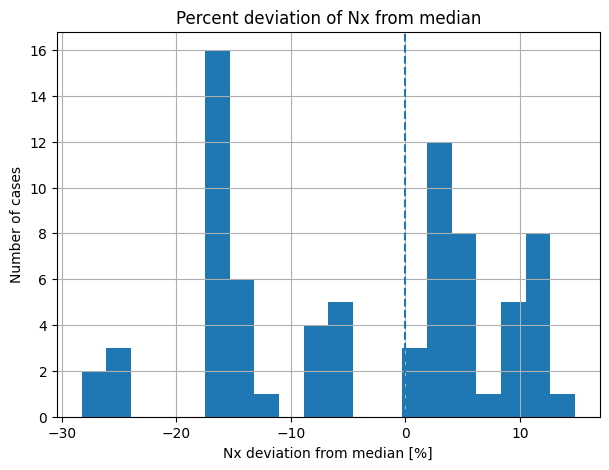

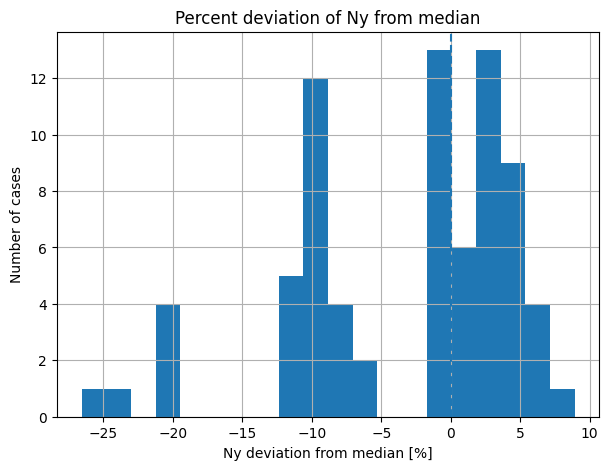

In [23]:
import matplotlib.pyplot as plt

# Ha még nincs shape_df, akkor image_info_dict-ből létrehozzuk
shape_df = pd.DataFrame.from_dict(image_info_dict, orient="index")
shape_df.index.name = "ID"

shapes = np.array(shape_df["spatial_shape"].tolist(), dtype=float)

shape_df["Nx"] = shapes[:, 0]
shape_df["Ny"] = shapes[:, 1]
shape_df["Nz"] = shapes[:, 2]

# Mediánok
median_x = shape_df["Nx"].median()
median_y = shape_df["Ny"].median()

print("Median Nx:", median_x)
print("Median Ny:", median_y)

# Százalékos eltérés a mediántól
shape_df["Nx_dev_percent"] = 100 * (shape_df["Nx"] - median_x) / median_x
shape_df["Ny_dev_percent"] = 100 * (shape_df["Ny"] - median_y) / median_y

# Statisztikák
stats_xy = shape_df[["Nx", "Ny", "Nx_dev_percent", "Ny_dev_percent"]].describe()
display(stats_xy)

print("Nx min / median / mean / max:")
print(shape_df["Nx"].min(), shape_df["Nx"].median(), shape_df["Nx"].mean(), shape_df["Nx"].max())

print("\nNy min / median / mean / max:")
print(shape_df["Ny"].min(), shape_df["Ny"].median(), shape_df["Ny"].mean(), shape_df["Ny"].max())

print("\nNx percent deviation min / median / mean / max:")
print(
    shape_df["Nx_dev_percent"].min(),
    shape_df["Nx_dev_percent"].median(),
    shape_df["Nx_dev_percent"].mean(),
    shape_df["Nx_dev_percent"].max()
)

print("\nNy percent deviation min / median / mean / max:")
print(
    shape_df["Ny_dev_percent"].min(),
    shape_df["Ny_dev_percent"].median(),
    shape_df["Ny_dev_percent"].mean(),
    shape_df["Ny_dev_percent"].max()
)

# Nx százalékos eltérés plot
plt.figure(figsize=(7, 5))
plt.hist(shape_df["Nx_dev_percent"], bins=20)
plt.axvline(0, linestyle="--")
plt.xlabel("Nx deviation from median [%]")
plt.ylabel("Number of cases")
plt.title("Percent deviation of Nx from median")
plt.grid(True)
plt.show()

# Ny százalékos eltérés plot
plt.figure(figsize=(7, 5))
plt.hist(shape_df["Ny_dev_percent"], bins=20)
plt.axvline(0, linestyle="--")
plt.xlabel("Ny deviation from median [%]")
plt.ylabel("Number of cases")
plt.title("Percent deviation of Ny from median")
plt.grid(True)
plt.show()

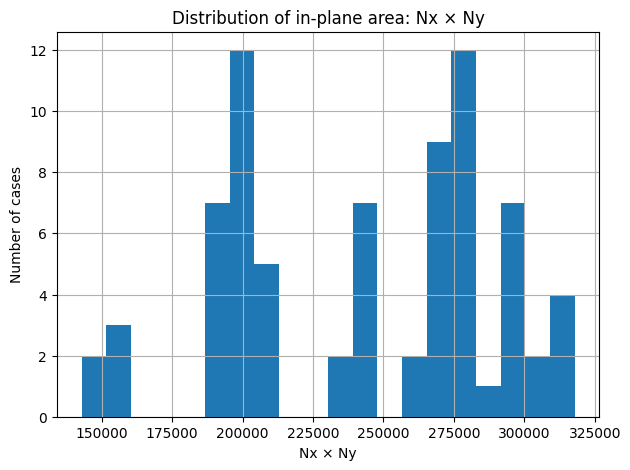

In [24]:
# Felület = első két spatial_shape koordináta szorzata
shape_df["Nxy_area"] = shape_df["Nx"] * shape_df["Ny"]

plt.figure(figsize=(7, 5))
plt.hist(shape_df["Nxy_area"], bins=20)
plt.xlabel("Nx × Ny")
plt.ylabel("Number of cases")
plt.title("Distribution of in-plane area: Nx × Ny")
plt.grid(True)
plt.show()

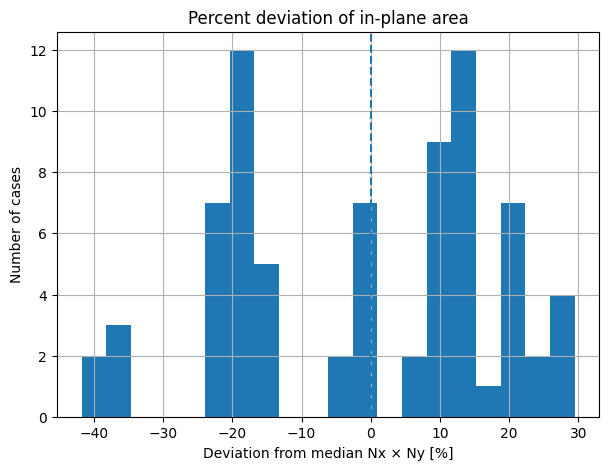

In [25]:
median_area = shape_df["Nxy_area"].median()
shape_df["Nxy_area_dev_percent"] = 100 * (shape_df["Nxy_area"] - median_area) / median_area

plt.figure(figsize=(7, 5))
plt.hist(shape_df["Nxy_area_dev_percent"], bins=20)
plt.axvline(0, linestyle="--")
plt.xlabel("Deviation from median Nx × Ny [%]")
plt.ylabel("Number of cases")
plt.title("Percent deviation of in-plane area")
plt.grid(True)
plt.show()

## TODO
    -SOT AI models proton dose prediction (DOTA baseline) (only CT-ből prediktáljon)
    -ray source information hogy lehet a legjobban enocodeolni

    
    -knowledge.md-t összerakni
    -find optimal pixel sizing, in ratio spatial shape!!!(százalékos eloszlás stb)
